In [1]:
import pandas as pd
import seaborn as sns

# the one and only network load for the whole project - everything
# after this point works off the saved CSV, never calls this again
df = sns.load_dataset('titanic')

# save immediately, before any cleaning/processing, so grading can run
# offline via pd.read_csv("titanic.csv") if sns.load_dataset can't reach
# the network at grading time
df.to_csv("titanic.csv", index=False)

print("Shape:", df.shape)

Shape: (891, 15)


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [3]:
print(df.describe())

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [4]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

print("Columns with missing values (%):")
print(missing_percentage)

Columns with missing values (%):
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64


In [5]:
print(df["deck"].unique())


[NaN, 'C', 'E', 'G', 'D', 'A', 'B', 'F']
Categories (7, str): ['A', 'B', 'C', 'D', 'E', 'F', 'G']


In [6]:
#Since the missing values are greater than 30% without randomness, remove the col from dataset 
df = df.drop(columns=["deck"])
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


In [7]:
# fill missing age with the median age within each pclass+sex group,
# since typical age varies a lot by class and gender on this dataset
before_missing = df["age"].isnull().sum()

# compute median age per pclass+sex group
group_medians = df.groupby(["pclass", "sex"])["age"].median().reset_index()
group_medians.columns = ["pclass", "sex", "age_median"]

# attach each row's group median as a new column
df = df.merge(group_medians, on=["pclass", "sex"], how="left")

# fill missing age using the attached group median, then drop the helper column
df["age"] = df["age"].fillna(df["age_median"])
df = df.drop(columns=["age_median"])

after_missing = df["age"].isnull().sum()
print(f"Missing age before: {before_missing}")
print(f"Missing age after: {after_missing}")

Missing age before: 177
Missing age after: 0


In [8]:
print("embarked unique values:", df["embarked"].unique())
print("embark_town unique values:", df["embark_town"].unique())

embarked unique values: <StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str
embark_town unique values: <StringArray>
['Southampton', 'Cherbourg', 'Queenstown', nan]
Length: 4, dtype: str


In [9]:
#since the embarked col has the values with the first letter of the values of embarked town 
#so dropping the embarked town col

df = df.drop(columns=["embark_town"])
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'alive', 'alone']


In [10]:
before_rows = len(df)
#Since there are only 2 empty values in embarked col,deleting those two rows which doesnot affect remaining data

df = df.dropna(subset=["embarked"])

after_rows = len(df)
print(f"Rows before: {before_rows}")
print(f"Rows after: {after_rows}")
print(f"Rows dropped: {before_rows - after_rows}")

Rows before: 891
Rows after: 889
Rows dropped: 2


In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

print("Columns with missing values (%):")
print(missing_percentage)

Columns with missing values (%):
Series([], dtype: float64)


In [12]:
#since the survived col has the values with 0 or 1 if the values of alive(0-no,1-yes) so drop alive col

df = df.drop(columns=["alive"])
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'alone']


In [13]:
print(df["survived"].unique())
print(df["adult_male"].unique())
df["who"].unique()


[0 1]
[ True False]


<StringArray>
['man', 'woman', 'child']
Length: 3, dtype: str

In [14]:
#since the sex col has the values with male or female if the values of adult_male(False-female,True-male) so drop adult_male col

df = df.drop(columns=["adult_male"])
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'alone']


In [15]:
#since the pclass col has the values 1,2,3 if the values of class(1-first,2-second,3-third) so drop class col

df = df.drop(columns=["class"])
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'who', 'alone']


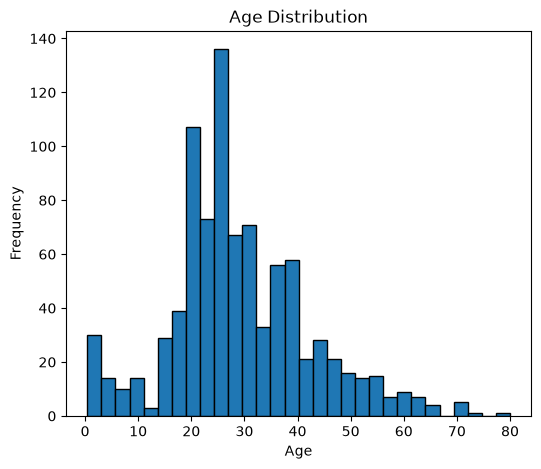

In [16]:

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))
plt.hist(df["age"], bins=30, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

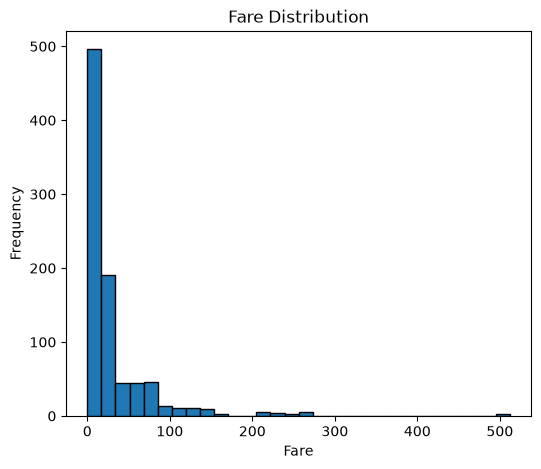

In [17]:
plt.figure(figsize=(6, 5))
plt.hist(df["fare"], bins=30, edgecolor="black")
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

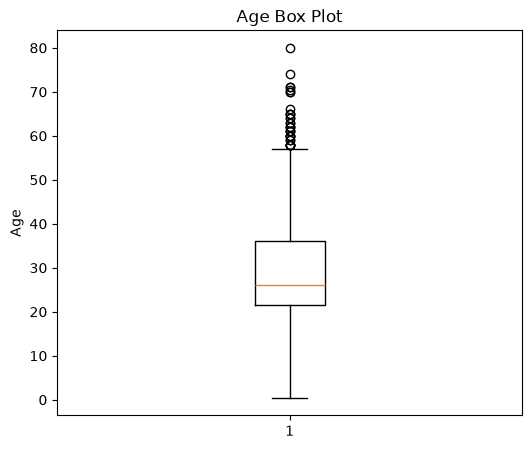

In [18]:
plt.figure(figsize=(6, 5))
plt.boxplot(df["age"])
plt.title("Age Box Plot")
plt.ylabel("Age")
plt.show()

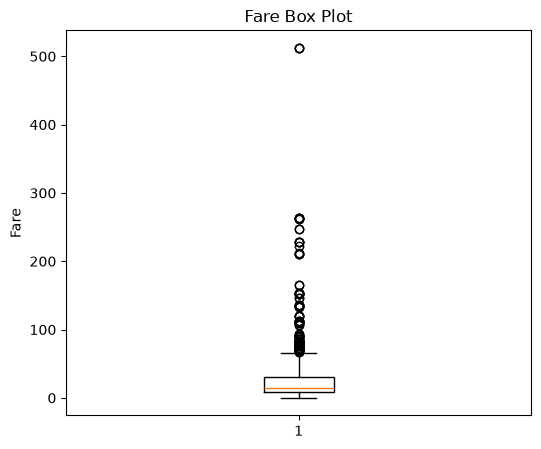

In [19]:
plt.figure(figsize=(6, 5))
plt.boxplot(df["fare"])
plt.title("Fare Box Plot")
plt.ylabel("Fare")
plt.show()

In [20]:
q1_age = df["age"].quantile(0.25)
q3_age = df["age"].quantile(0.75)
iqr_age = q3_age - q1_age

lower_bound_age = q1_age - 1.5 * iqr_age
upper_bound_age = q3_age + 1.5 * iqr_age

age_outliers = df[(df["age"] < lower_bound_age) | (df["age"] > upper_bound_age)]

print(f"Age Q1: {q1_age}, Q3: {q3_age}, IQR: {iqr_age}")
print(f"Age lower bound: {lower_bound_age}, upper bound: {upper_bound_age}")
print(f"Number of age outliers: {len(age_outliers)}")

Age Q1: 21.5, Q3: 36.0, IQR: 14.5
Age lower bound: -0.25, upper bound: 57.75
Number of age outliers: 32


In [21]:
q1_fare = df["fare"].quantile(0.25)
q3_fare = df["fare"].quantile(0.75)
iqr_fare = q3_fare - q1_fare

lower_bound_fare = q1_fare - 1.5 * iqr_fare
upper_bound_fare = q3_fare + 1.5 * iqr_fare

fare_outliers = df[(df["fare"] < lower_bound_fare) | (df["fare"] > upper_bound_fare)]

print(f"Fare Q1: {q1_fare}, Q3: {q3_fare}, IQR: {iqr_fare}")
print(f"Fare lower bound: {lower_bound_fare}, upper bound: {upper_bound_fare}")
print(f"Number of fare outliers: {len(fare_outliers)}")

Fare Q1: 7.8958, Q3: 31.0, IQR: 23.1042
Fare lower bound: -26.7605, upper bound: 65.6563
Number of fare outliers: 114


In [22]:
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]

print(f"Fare mean: {fare_mean}")
print(f"Fare median: {fare_median}")
print(f"Fare mode: {fare_mode}")


Fare mean: 32.09668087739032
Fare median: 14.4542
Fare mode: 8.05


In [23]:
print(f"Mean: {fare_mean}")
print(f"Median: {fare_median}")
print(f"Mode: {fare_mode}")
print()

if fare_mean > fare_median > fare_mode:
    skew_direction = "right-skewed (long tail toward high values)"
elif fare_mean < fare_median < fare_mode:
    skew_direction = "left-skewed (long tail toward low values)"
else:
    skew_direction = "roughly symmetric"

print(f"Fare distribution appears to be: {skew_direction}")
print(f"Reasoning: mean ({fare_mean:.2f}) vs median ({fare_median:.2f}) vs mode ({fare_mode:.2f})")

Mean: 32.09668087739032
Median: 14.4542
Mode: 8.05

Fare distribution appears to be: right-skewed (long tail toward high values)
Reasoning: mean (32.10) vs median (14.45) vs mode (8.05)


In [24]:
male_survival_rate = df[df["sex"] == "male"]["survived"].mean()
female_survival_rate = df[df["sex"] == "female"]["survived"].mean()

print(f"Male survival rate: {male_survival_rate:.4f}")
print(f"Female survival rate: {female_survival_rate:.4f}")

Male survival rate: 0.1889
Female survival rate: 0.7404


In [25]:
class1_survival_rate = df[df["pclass"] == 1]["survived"].mean()
class2_survival_rate = df[df["pclass"] == 2]["survived"].mean()
class3_survival_rate = df[df["pclass"] == 3]["survived"].mean()

print(f"1st class survival rate: {class1_survival_rate:.4f}")
print(f"2nd class survival rate: {class2_survival_rate:.4f}")
print(f"3rd class survival rate: {class3_survival_rate:.4f}")

1st class survival rate: 0.6262
2nd class survival rate: 0.4728
3rd class survival rate: 0.2424


In [26]:
female_class1 = df[(df["sex"] == "female") & (df["pclass"] == 1)]["survived"].mean()
female_class2 = df[(df["sex"] == "female") & (df["pclass"] == 2)]["survived"].mean()
female_class3 = df[(df["sex"] == "female") & (df["pclass"] == 3)]["survived"].mean()

male_class1 = df[(df["sex"] == "male") & (df["pclass"] == 1)]["survived"].mean()
male_class2 = df[(df["sex"] == "male") & (df["pclass"] == 2)]["survived"].mean()
male_class3 = df[(df["sex"] == "male") & (df["pclass"] == 3)]["survived"].mean()

print(f"Female, 1st class: {female_class1:.4f}")
print(f"Female, 2nd class: {female_class2:.4f}")
print(f"Female, 3rd class: {female_class3:.4f}")
print(f"Male, 1st class: {male_class1:.4f}")
print(f"Male, 2nd class: {male_class2:.4f}")
print(f"Male, 3rd class: {male_class3:.4f}")

Female, 1st class: 0.9674
Female, 2nd class: 0.9211
Female, 3rd class: 0.5000
Male, 1st class: 0.3689
Male, 2nd class: 0.1574
Male, 3rd class: 0.1354


In [27]:
corr_columns = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr_matrix = df[corr_columns].corr()

print(corr_matrix)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.064411 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.410697  0.081656  0.016824 -0.548193
age      -0.064411 -0.410697  1.000000 -0.249161 -0.174541  0.119859
sibsp    -0.034040  0.081656 -0.249161  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.174541  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.119859  0.160887  0.217532  1.000000


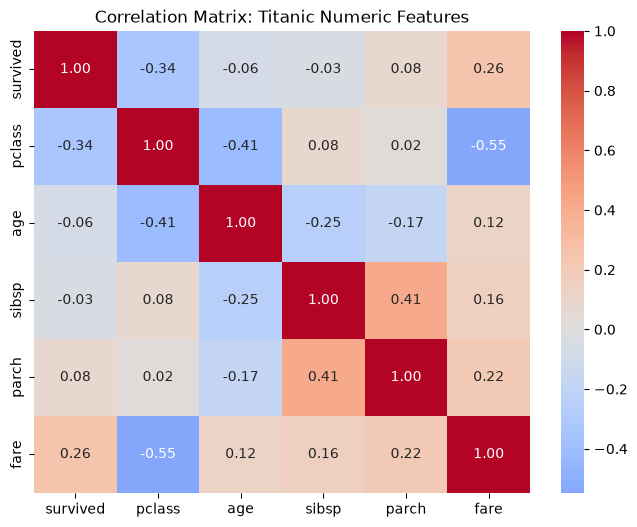

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix: Titanic Numeric Features")
plt.show()

In [29]:
# unstack the matrix into (row, col) -> correlation pairs
corr_pairs = corr_matrix.unstack()

# drop self-correlations (always 1.0, e.g. survived-survived)
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# each pair appears twice (a-b and b-a) since the matrix is symmetric,
# so keep only one direction to avoid counting the same pair twice
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) < corr_pairs.index.get_level_values(1)]

# rank by absolute value, since a strong negative correlation matters
# just as much as a strong positive one
top_2 = corr_pairs.abs().sort_values(ascending=False).head(2)

print("Two strongest correlations (by absolute value):")
for pair, abs_value in top_2.items():
    actual_value = corr_pairs[pair]
    print(f"{pair[0]} vs {pair[1]}: correlation = {actual_value:.4f}")

Two strongest correlations (by absolute value):
fare vs pclass: correlation = -0.5482
parch vs sibsp: correlation = 0.4145


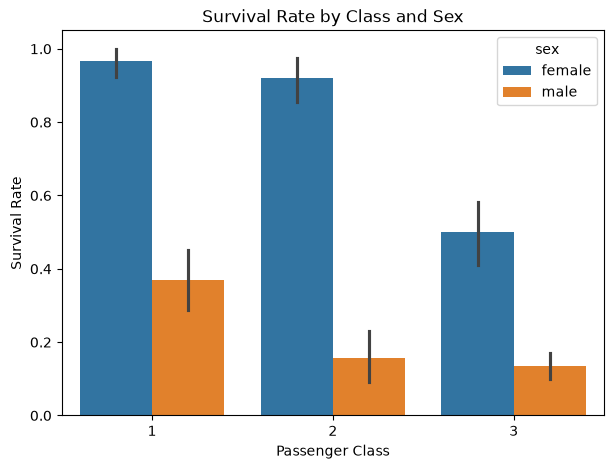

In [30]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x="pclass", y="survived", hue="sex")
plt.title("Survival Rate by Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

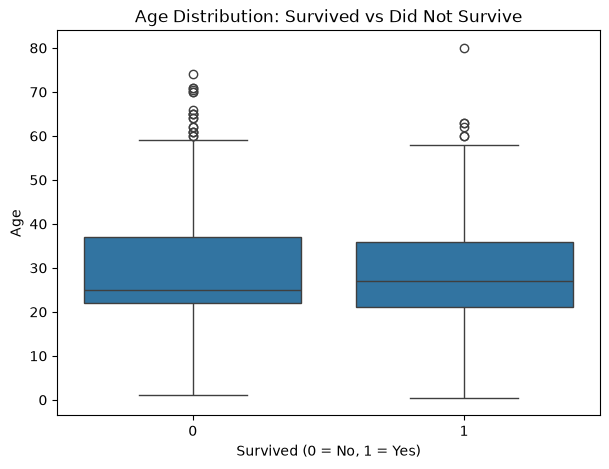

In [31]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="survived", y="age")
plt.title("Age Distribution: Survived vs Did Not Survive")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

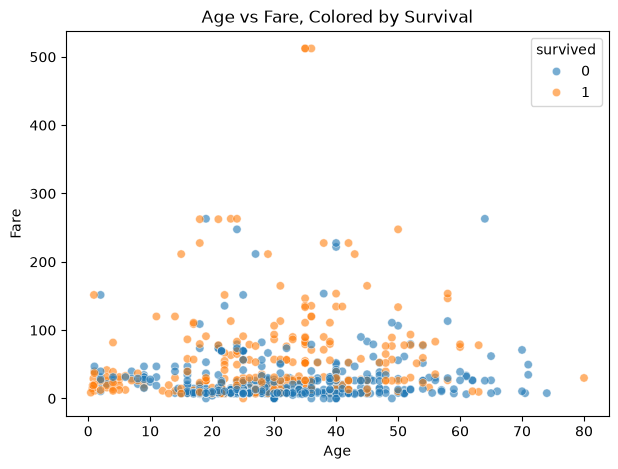

In [32]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="age", y="fare", hue="survived", alpha=0.6)
plt.title("Age vs Fare, Colored by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

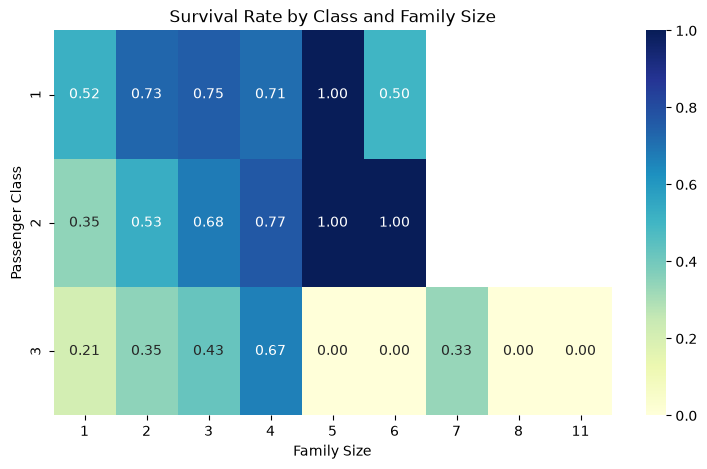

In [33]:
# family_size created here for this chart only, to test whether
# traveling with a small family (vs alone, or a large family) affected survival
df["family_size"] = df["sibsp"] + df["parch"] + 1

pivot = df.pivot_table(values="survived", index="pclass", columns="family_size", aggfunc="mean")

plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Survival Rate by Class and Family Size")
plt.xlabel("Family Size")
plt.ylabel("Passenger Class")
plt.show()

In [34]:
# before: original mean and std
print("BEFORE standardization:")
print(f"age  -> mean: {df['age'].mean():.4f}, std: {df['age'].std():.4f}")
print(f"fare -> mean: {df['fare'].mean():.4f}, std: {df['fare'].std():.4f}")

# manual z-score formula: z = (x - mean) / std
# stored in new columns so the original age/fare are untouched -
# this is a standalone EDA check, not something the modeling pipeline reuses
df["age_zscore"] = (df["age"] - df["age"].mean()) / df["age"].std()
df["fare_zscore"] = (df["fare"] - df["fare"].mean()) / df["fare"].std()

print()
print("AFTER standardization:")
print(f"age_zscore  -> mean: {df['age_zscore'].mean():.4f}, std: {df['age_zscore'].std():.4f}")
print(f"fare_zscore -> mean: {df['fare_zscore'].mean():.4f}, std: {df['fare_zscore'].std():.4f}")

BEFORE standardization:
age  -> mean: 29.0654, std: 13.2702
fare -> mean: 32.0967, std: 49.6975

AFTER standardization:
age_zscore  -> mean: 0.0000, std: 1.0000
fare_zscore -> mean: 0.0000, std: 1.0000


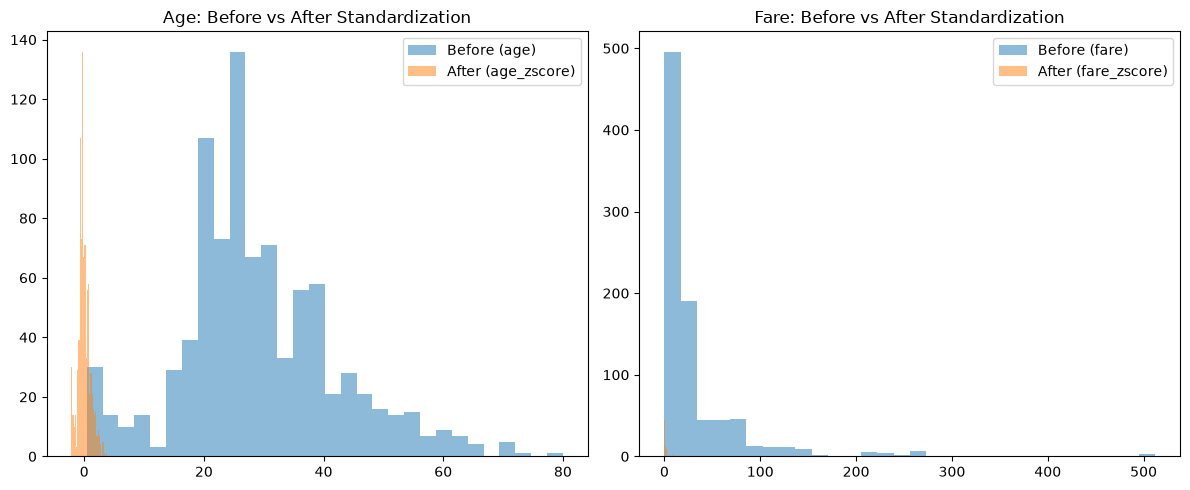

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["age"], bins=30, alpha=0.5, label="Before (age)")
axes[0].hist(df["age_zscore"], bins=30, alpha=0.5, label="After (age_zscore)")
axes[0].set_title("Age: Before vs After Standardization")
axes[0].legend()

axes[1].hist(df["fare"], bins=30, alpha=0.5, label="Before (fare)")
axes[1].hist(df["fare_zscore"], bins=30, alpha=0.5, label="After (fare_zscore)")
axes[1].set_title("Fare: Before vs After Standardization")
axes[1].legend()

plt.tight_layout()
plt.show()

In [39]:
# sex: binary category -> map directly to 0/1
df["sex"] = df["sex"].map({"male": 0, "female": 1})

# embarked: 3 unordered categories (S/C/Q) -> one-hot encoding,
# since there's no natural ranking between ports
df = pd.get_dummies(df, columns=["embarked"], prefix="embarked")

# who: 3 unordered categories (man/woman/child) -> one-hot encoding
df = pd.get_dummies(df, columns=["who"], prefix="who")

# alone: already boolean True/False -> convert directly to 0/1 int
df["alone"] = df["alone"].astype(int)

print(df.columns.tolist())
print(df.head())

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'alone', 'family_size', 'age_zscore', 'fare_zscore', 'embarked_C', 'embarked_Q', 'embarked_S', 'who_child', 'who_man', 'who_woman']
   survived  pclass  sex   age  sibsp  parch     fare  alone  family_size  \
0         0       3    0  22.0      1      0   7.2500      0            2   
1         1       1    1  38.0      1      0  71.2833      0            2   
2         1       3    1  26.0      0      0   7.9250      1            1   
3         1       1    1  35.0      1      0  53.1000      0            2   
4         0       3    0  35.0      0      0   8.0500      1            1   

   age_zscore  fare_zscore  embarked_C  embarked_Q  embarked_S  who_child  \
0   -0.532430    -0.499958       False       False        True      False   
1    0.673282     0.788503        True       False       False      False   
2   -0.231002    -0.486376       False       False        True      False   
3    0.447211     0.422623       F

In [41]:
clean_df = df.copy()

clean_df.to_csv("titanic_clean.csv", index=False)

print(f"Saved cleaned dataset with {len(clean_df)} rows and {len(clean_df.columns)} columns")
print(clean_df.columns.tolist())

Saved cleaned dataset with 889 rows and 17 columns
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'alone', 'family_size', 'age_zscore', 'fare_zscore', 'embarked_C', 'embarked_Q', 'embarked_S', 'who_child', 'who_man', 'who_woman']
